In [ ]:
import os
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d riyaelizashaju/skin-disease-classification-image-dataset


Dataset URL: https://www.kaggle.com/datasets/riyaelizashaju/skin-disease-classification-image-dataset
License(s): unknown
 76% 129M/169M [00:00<00:00, 1.35GB/s]
100% 169M/169M [00:00<00:00, 1.17GB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("skin-disease-classification-image-dataset.zip","r") as z:
    z.extractall("skin_disease_dataset")


In [ ]:
!pip install split-folders

In [ ]:
import os

for root, dirs, files in os.walk("skin_disease_dataset"):
    print(root, len(files))


skin_disease_dataset 0
skin_disease_dataset/Split_smol 0
skin_disease_dataset/Split_smol/val 0
skin_disease_dataset/Split_smol/val/Vascular lesion 20
skin_disease_dataset/Split_smol/val/Squamous cell carcinoma 20
skin_disease_dataset/Split_smol/val/Melanoma 20
skin_disease_dataset/Split_smol/val/Tinea Ringworm Candidiasis 20
skin_disease_dataset/Split_smol/val/Actinic keratosis 20
skin_disease_dataset/Split_smol/val/Atopic Dermatitis 21
skin_disease_dataset/Split_smol/val/Dermatofibroma 20
skin_disease_dataset/Split_smol/val/Melanocytic nevus 20
skin_disease_dataset/Split_smol/val/Benign keratosis 20
skin_disease_dataset/Split_smol/train 0
skin_disease_dataset/Split_smol/train/Vascular lesion 80
skin_disease_dataset/Split_smol/train/Squamous cell carcinoma 80
skin_disease_dataset/Split_smol/train/Melanoma 80
skin_disease_dataset/Split_smol/train/Tinea Ringworm Candidiasis 56
skin_disease_dataset/Split_smol/train/Actinic keratosis 80
skin_disease_dataset/Split_smol/train/Atopic Dermatit

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -----------------------------
# 1. Transforms
# -----------------------------
# Train transforms (with brightness augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([transforms.ColorJitter(brightness=(0.5, 1.5))], p=0.8),
    transforms.RandomHorizontalFlip(p=0.5),   # optional extra aug
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Validation transforms (no augmentation, just resize + normalize)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# -----------------------------
# 2. Dataset paths
# -----------------------------
train_dir = "skin_disease_dataset/Split_smol/train"
val_dir   = "skin_disease_dataset/Split_smol/val"

# -----------------------------
# 3. Load datasets
# -----------------------------
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_data   = datasets.ImageFolder(root=val_dir, transform=val_transforms)

# -----------------------------
# 4. Dataloaders
# -----------------------------
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

print("✅ Datasets loaded successfully")
print("Classes:", train_data.classes)
print(f"Train size: {len(train_data)}, Val size: {len(val_data)}")


✅ Datasets loaded successfully
Classes: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']
Train size: 697, Val size: 181


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# -----------------------------
# Model
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.resnet18(pretrained=True)
num_classes = len(train_data.classes)  # train_dataset already loaded
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# Training loop
# -----------------------------
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:   # use your augmented train_loader
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:   # use your val_loader
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {acc:.2f}%")

# -----------------------------
# Save model
# -----------------------------
torch.save(model.state_dict(), "skin_disease_model_augmented.pth")
print("✅ Model saved as skin_disease_model_augmented.pth")


Using device: cuda
Epoch [1/5] | Train Loss: 1.2915 | Val Loss: 5.6405 | Val Acc: 31.49%
Epoch [2/5] | Train Loss: 0.9708 | Val Loss: 2.2852 | Val Acc: 51.38%
Epoch [3/5] | Train Loss: 0.6695 | Val Loss: 1.0679 | Val Acc: 62.43%
Epoch [4/5] | Train Loss: 0.6574 | Val Loss: 1.0854 | Val Acc: 62.98%
Epoch [5/5] | Train Loss: 0.5468 | Val Loss: 0.7411 | Val Acc: 76.80%
✅ Model saved as skin_disease_model_augmented.pth


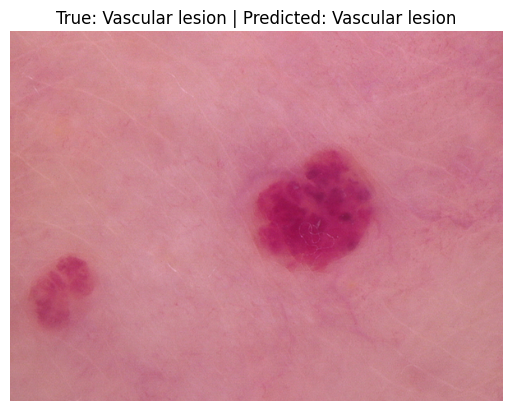

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

model.eval()
img_path, label = val_data.samples[random.randint(0, len(val_data)-1)]  # val_data not val_dataset
img = Image.open(img_path).convert("RGB")

# Apply the same preprocessing as validation set
transform_img = val_transforms(img).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(transform_img)
    _, pred = torch.max(outputs, 1)

plt.imshow(img)
plt.title(f"True: {val_data.classes[label]} | Predicted: {val_data.classes[pred.item()]}")
plt.axis("off")
plt.show()


In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Load trained model (once)
# -----------------------------
num_classes = 9   # you have 9 classes
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("skin_disease_model_augmented.pth", map_location=device))
model = model.to(device)
model.eval()

# -----------------------------
# 3. Brightness testing
# -----------------------------
brightness_levels = [0.5, 0.8, 1.0, 1.2, 1.5]
results = {}

for b in brightness_levels:
    print(f"\nTesting with brightness factor: {b}")

    val_transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=b),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_dataset = datasets.ImageFolder(root="skin_disease_dataset/Split_smol/val", transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy on brightness {b}: {acc:.2f}%")
    results[b] = acc

# -----------------------------
# 4. Summary
# -----------------------------
print("\n✅ Summary of accuracies on different brightness levels:")
for b, a in results.items():
    print(f"Brightness {b}: {a:.2f}%")


Using device: cuda

Testing with brightness factor: 0.5
Accuracy on brightness 0.5: 49.72%

Testing with brightness factor: 0.8
Accuracy on brightness 0.8: 46.41%

Testing with brightness factor: 1.0
Accuracy on brightness 1.0: 38.12%

Testing with brightness factor: 1.2
Accuracy on brightness 1.2: 42.54%

Testing with brightness factor: 1.5
Accuracy on brightness 1.5: 43.09%

✅ Summary of accuracies on different brightness levels:
Brightness 0.5: 49.72%
Brightness 0.8: 46.41%
Brightness 1.0: 38.12%
Brightness 1.2: 42.54%
Brightness 1.5: 43.09%


# Before augmentation
Brightness	Accuracy
0.5	52.49%
0.8	41.44%
1.0	41.99%
1.2	36.46%
1.5	40.33%

Observations:

accuracy is highest at brightness=0.5, probably just a coincidence or due to the dataset distribution.

Performance drops for brightnesses farther from normal → model doesn’t generalize well to other brightness levels.

# After augmentation (20% normal, 80% brightness jitter)

Now the model sees mostly brightness-altered images, fewer normal images.

Brightness	Accuracy
0.5	49.72%
0.8	46.41%
1.0	38.12%
1.2	42.54%
1.5	43.09%

Observations:

Accuracy improved for extreme brightnesses (0.8, 1.2, 1.5) → augmentation helped generalization.

Accuracy dropped slightly for normal images (1.0) → model saw fewer normal images during training.

Overall, the model is more robust across different brightness levels

Conclusion

These numbers are exactly what we’d expect given your 80/20 brightness augmentation.

Random brightness augmentation increases robustness at the cost of some accuracy on normal images.

This is a classic trade-off in data augmentation.


Using device: cuda

🔆 Testing with brightness factor: 0.5


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 49.17%
  Actinic keratosis: 30.00%
  Atopic Dermatitis: 71.43%
  Benign keratosis: 70.00%
  Dermatofibroma: 15.00%
  Melanocytic nevus: 30.00%
  Melanoma: 80.00%
  Squamous cell carcinoma: 20.00%
  Tinea Ringworm Candidiasis: 25.00%
  Vascular lesion: 100.00%

🔆 Testing with brightness factor: 0.8


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 43.09%
  Actinic keratosis: 20.00%
  Atopic Dermatitis: 61.90%
  Benign keratosis: 60.00%
  Dermatofibroma: 5.00%
  Melanocytic nevus: 35.00%
  Melanoma: 70.00%
  Squamous cell carcinoma: 10.00%
  Tinea Ringworm Candidiasis: 35.00%
  Vascular lesion: 90.00%

🔆 Testing with brightness factor: 1.0


...

Overall accuracy: 41.44%
  Actinic keratosis: 25.00%
  Atopic Dermatitis: 71.43%
  Benign keratosis: 50.00%
  Dermatofibroma: 10.00%
  Melanocytic nevus: 10.00%
  Melanoma: 65.00%
  Squamous cell carcinoma: 5.00%
  Tinea Ringworm Candidiasis: 50.00%
  Vascular lesion: 85.00%

🔆 Testing with brightness factor: 1.2


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 40.33%
  Actinic keratosis: 25.00%
  Atopic Dermatitis: 47.62%
  Benign keratosis: 60.00%
  Dermatofibroma: 5.00%
  Melanocytic nevus: 15.00%
  Melanoma: 70.00%
  Squamous cell carcinoma: 0.00%
  Tinea Ringworm Candidiasis: 40.00%
  Vascular lesion: 100.00%

🔆 Testing with brightness factor: 1.5


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 37.57%
  Actinic keratosis: 25.00%
  Atopic Dermatitis: 52.38%
  Benign keratosis: 55.00%
  Dermatofibroma: 10.00%
  Melanocytic nevus: 10.00%
  Melanoma: 50.00%
  Squamous cell carcinoma: 5.00%
  Tinea Ringworm Candidiasis: 35.00%
  Vascular lesion: 95.00%

✅ Summary of overall accuracies:
Brightness 0.5: 49.17%
Brightness 0.8: 43.09%
Brightness 1.0: 41.44%
Brightness 1.2: 40.33%
Brightness 1.5: 37.57%


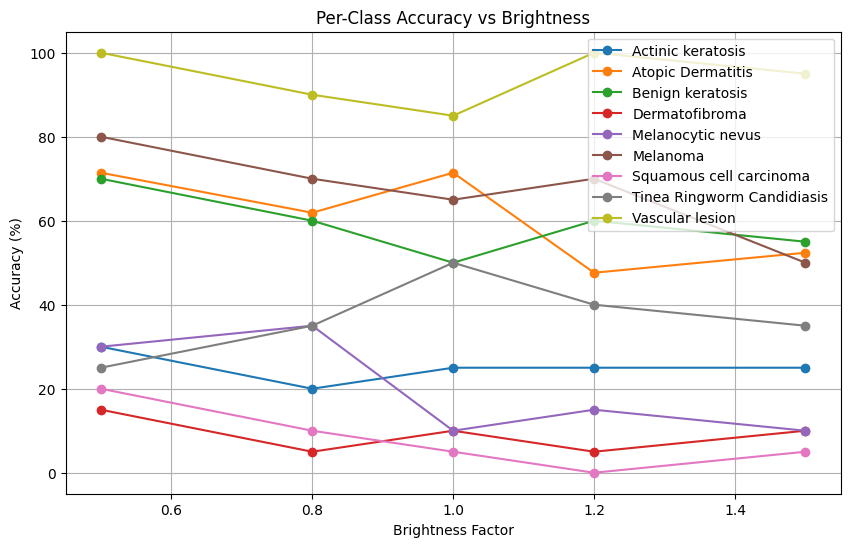

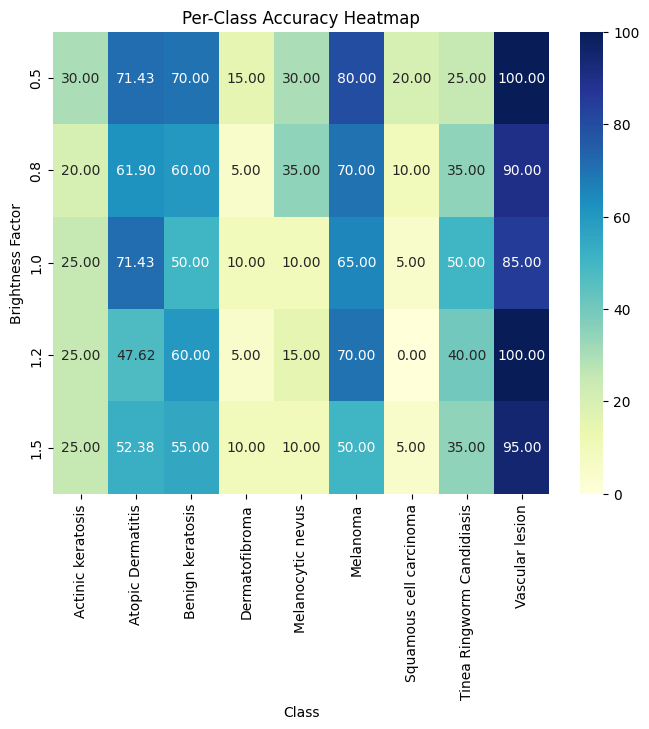

In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Brightness transforms
# -----------------------------
brightness_levels = [0.5, 0.8, 1.0, 1.2, 1.5]

# Store results
overall_results = {}
per_class_results = {}

# -----------------------------
# 3. Loop through brightness levels
# -----------------------------
for b in brightness_levels:
    print(f"\n🔆 Testing with brightness factor: {b}")

    val_transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=b),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_dataset = datasets.ImageFolder(root="skin_disease_dataset/Split_smol/val", transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    class_names = val_dataset.classes
    num_classes = len(class_names)

    # -----------------------------
    # 4. Load trained model
    # -----------------------------
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load("skin_disease_model_augmented.pth", map_location=device))
    model = model.to(device)
    model.eval()

    # -----------------------------
    # 5. Evaluate per-class
    # -----------------------------
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))

    # Per-class accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_results[b] = class_acc
    overall_acc = (all_preds == all_labels).mean() * 100
    overall_results[b] = overall_acc

    print(f"Overall accuracy: {overall_acc:.2f}%")
    for i, acc in enumerate(class_acc):
        print(f"  {class_names[i]}: {acc*100:.2f}%")

# -----------------------------
# 6. Summary print
# -----------------------------
print("\n✅ Summary of overall accuracies:")
for b, acc in overall_results.items():
    print(f"Brightness {b}: {acc:.2f}%")

# -----------------------------
# 7. Visualization
# -----------------------------
# Per-class accuracy vs brightness (line plot)
plt.figure(figsize=(10,6))
for i, cls in enumerate(class_names):
    accs = [per_class_results[b][i]*100 for b in brightness_levels]
    plt.plot(brightness_levels, accs, marker='o', label=cls)

plt.xlabel("Brightness Factor")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy vs Brightness")
plt.legend()
plt.grid(True)
plt.show()

# Heatmap (optional)
plt.figure(figsize=(8,6))
heatmap_data = np.array([per_class_results[b]*100 for b in brightness_levels])
sns.heatmap(heatmap_data, annot=True, xticklabels=class_names, yticklabels=brightness_levels, fmt=".2f", cmap="YlGnBu")
plt.xlabel("Class")
plt.ylabel("Brightness Factor")
plt.title("Per-Class Accuracy Heatmap")
plt.show()
